# Active Discovery of Latent Dynamic Mediators

To start we assume that in our training set we have recordings of $N$ independent patients. Each patient $n$ is associated with two time series signals, $x_n(t)$ and $y_n(t)$, and a treatment group label $c_n \in \mathcal{C}$ provided by an expert. The treatment group $c_n$ identifies which causal pathway is responsible for generating $y_n(t)$. The pathway $c_n$ is associated with a particular causal model $M_{c_n}$ that generated $y_n(t)$  conditional on a latent mediation process $z_n(t)$.

There are two SSMs indexed by $j\in \{0,1\}$, where $j$ represents the group:
$$z_t := \alpha_j x_t + \lambda_j z_{t-1} + w_t,
    \qquad w \sim \mathcal{N}(0,\sigma_w)$$
$$y_t := \beta_j z_{t} + \gamma_j x_t + e_t,
    \qquad e_t \sim \mathcal{N}(0,\sigma_e)
$$

In [7]:
from utils.data_generation import generate_synthetic_samples
from utils.plots import plot_scatter_by_group, plot_trajectories, plot_mean_std
from utils.em_algorithm import em_ssm

## Phase 1: training

### Data Visualization

In [2]:
# generate synthetic training samples
j_train, X_train, Z_train, Y_train = generate_synthetic_samples(n_patients=100, T=50)

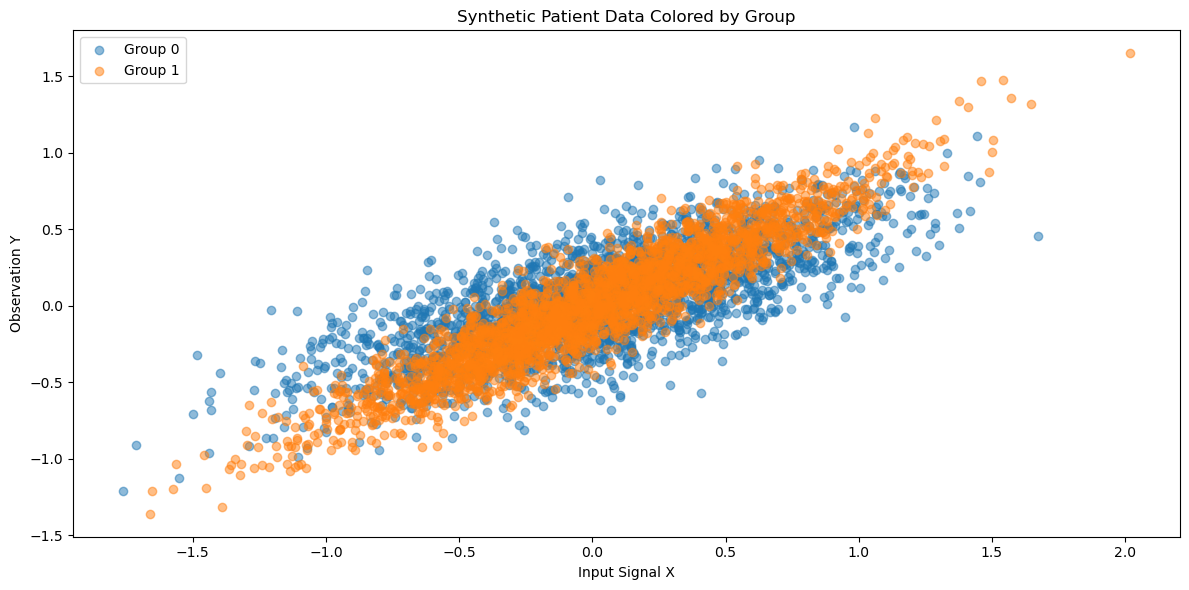

In [3]:
plot_scatter_by_group(X_train, Y_train, groups=j_train)

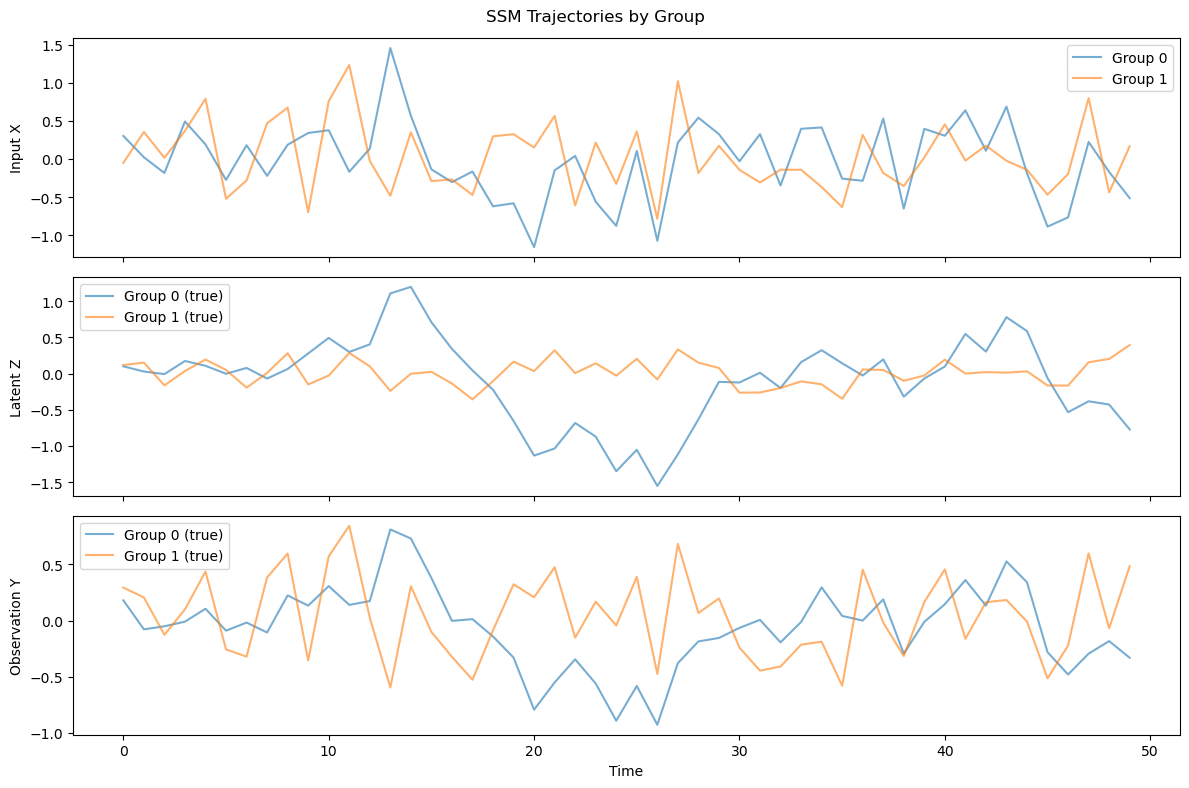

In [4]:
plot_trajectories(X_train, Z_train, Y_train, groups=j_train)

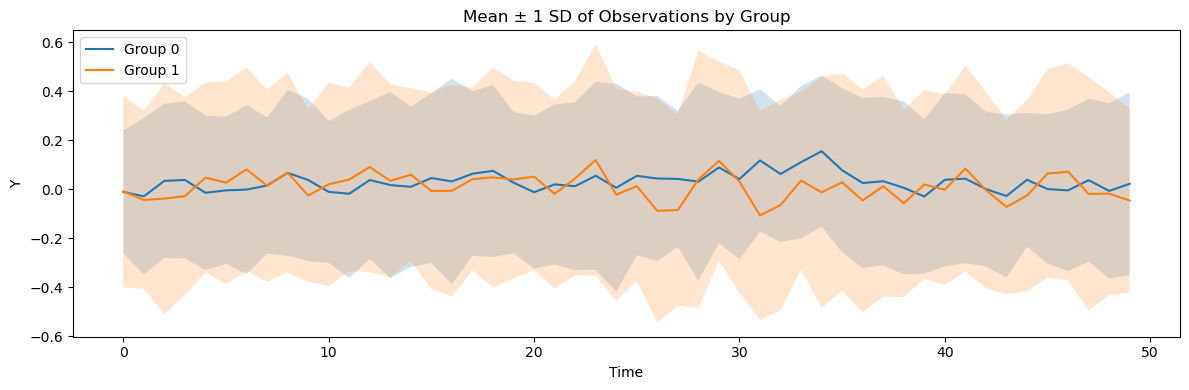

In [5]:
plot_mean_std(Y_train, groups=j_train)

### Estimation using EM algorithm

In [10]:
# separate the data into the two groups
# run em algorithm on each group separately
estimated_params = {}
for group in [0, 1]:
        idx = j_train == group
        X_group = X_train[idx]
        Y_group = Y_train[idx]
 
        params, log_liks = em_ssm(
            X_group, Y_group,
            alpha_init=0.5, lam_init=0.5, beta_init=0.5, gamma_init=0.5,
            sigma_w_init=0.2, sigma_e_init=0.2,
        )

        estimated_params[group] = params
 
        print(f"\nGroup {group} estimated params:")
        for k, v in params.items():
            print(f"  {k}: {v:.4f}")
            #print(f"Log-likelihood: {log_liks}.")


Group 0 estimated params:
  alpha: 0.6259
  lam: 0.7996
  beta: 0.4734
  gamma: 0.1982
  sigma_w: 0.0987
  sigma_e: 0.1014

Group 1 estimated params:
  alpha: 0.6358
  lam: 0.4646
  beta: 0.3424
  gamma: 0.5484
  sigma_w: 0.2307
  sigma_e: 0.1067


In [ ]:
plot_trajectories(X_train, Z_train, Y_train, groups=j_train)

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
for group in [0, 1]:
    idx = (j_train == group)
    mean_y = Y_train[idx].mean(axis=0)
    std_y  = Y_train[idx].std(axis=0)
    t = np.arange(50)
    ax.plot(t, mean_y, label=f'Group {group}')
    ax.fill_between(t, mean_y - std_y, mean_y + std_y, alpha=0.2)

ax.set_xlabel('Time'); ax.set_ylabel('Y')
ax.set_title('Mean ± 1 SD of Observations by Group')
ax.legend()
plt.show()

NameError: name 'plt' is not defined

In [13]:
from utils import fit_mixture_ssm
# fit SSM parameters for each group
results_theta, loglik_theta = fit_mixture_ssm(j_train, X_train, Y_train)


Fitting group 0  (61 patients)
  Final log-lik : 2108.11
  alpha=0.406  lam=0.793  beta=0.758  gamma=0.195  sigma_w=0.065  sigma_e=0.098

Fitting group 1  (39 patients)
  Final log-lik : 1125.28
  alpha=0.459  lam=0.456  beta=0.484  gamma=0.549  sigma_w=0.153  sigma_e=0.109


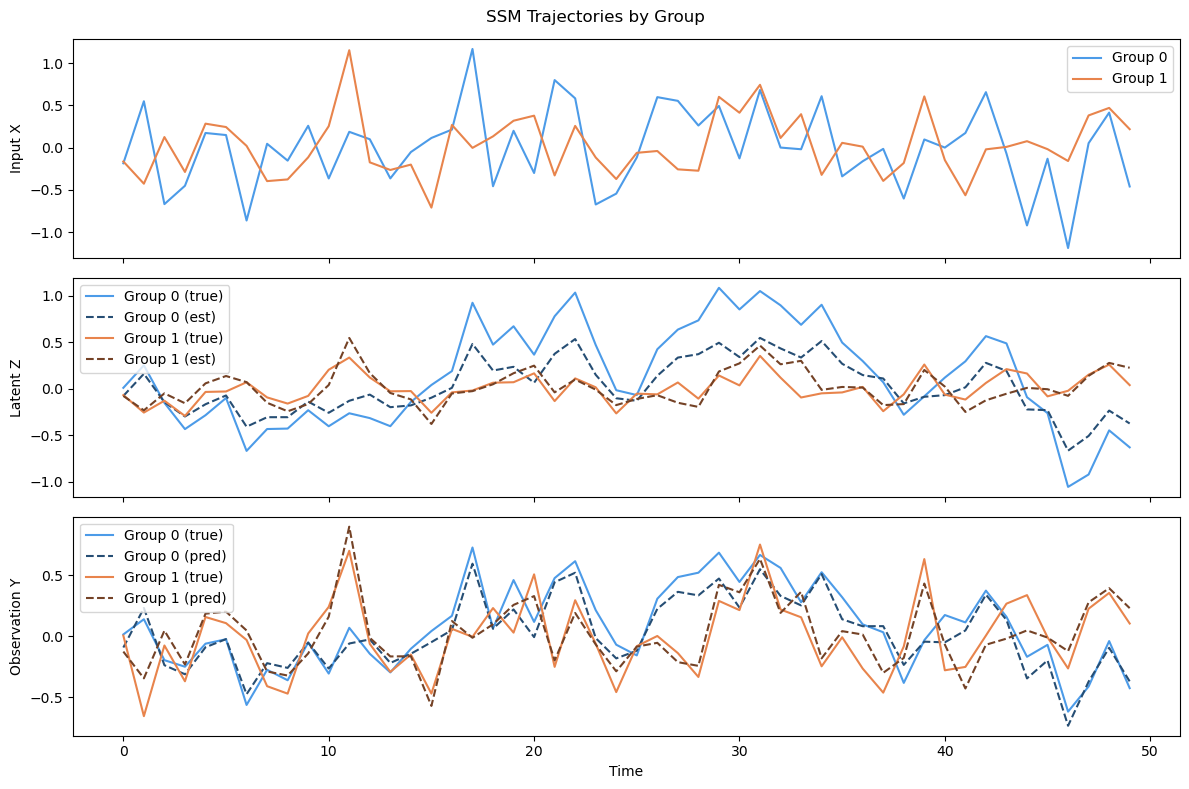

In [14]:
from plot_utils import plot_ssm_trajectories
plot_ssm_trajectories(X_train, Z_train, Y_train, j_train, estimated_params=results_theta)

## Phase 2: classification via filtering

In [15]:
# generate synthetic testing samples
j_test, X_test, Z_test, Y_test = generate_synthetic_samples(n_patients=20, T=50)

In [16]:
from utils import infer_patients
results = infer_patients(Y_test, X_test, results_theta[0], results_theta[1])

# results is a list of 50 dicts, one per patient
# pull out group assignments for all patients at once
j_pred = np.array([r['group'] for r in results])

# pull out smoothed trajectories as a matrix
Z_smooth = np.stack([r['z_smooth'] for r in results])  # (50, 50)
Z_filt   = np.stack([r['z_filt']   for r in results])  # (50, 50)

# -----------------------------------------------------------------------
# Things you might do with the results
# -----------------------------------------------------------------------

# 1. classification accuracy (if you have true labels)
acc = np.mean(j_pred == j_test)
print(f"Accuracy: {acc:.2%}")

# 2. 95% uncertainty band for one patient's smoothed trajectory
n   = 0
z_s = results[n]['z_smooth']
p_s = results[n]['P_smooth']
upper = z_s + 2 * np.sqrt(p_s)
lower = z_s - 2 * np.sqrt(p_s)

# 3. flag ambiguous patients -- small log-likelihood gap means uncertain
gaps = [abs(r['log_liks'][0] - r['log_liks'][1]) for r in results]
ambiguous = np.where(np.array(gaps) < 10)[0]
print(f"Ambiguous patients: {ambiguous}")

# 4. patients where the group assignment may be wrong
# (if you have true labels, look at misclassified ones)
wrong = np.where(j_pred != j_test)[0]
for n in wrong:
    print(f"Patient {n}: true={j_test[n]}, pred={j_pred[n]}, "
          f"ll_gap={gaps[n]:.1f}")

Accuracy: 100.00%
Ambiguous patients: []
